# Week 11 Notebook 1: Visual Understanding Basics

This notebook supports the **Vision and Multimodal Intelligence** part of the lecture.

## What this notebook covers
- Images as numerical data
- Visual embeddings
- Similarity search with image embeddings
- Basic zero-shot image tagging

## Lecture sections covered
- Section 3: Understanding Images as Data
- Section 4: Image Representations & Visual Embeddings
- Section 8: Tagging, Labeling, and Confidence

## Goal of this demo
1. Show that an image is just a matrix of numbers.
2. Generate embeddings for a few images.
3. Compare image similarity in embedding space.
4. Run simple zero-shot tagging with confidence-like scores.
5. Connect this back to Week 8 text embeddings.

## 0. Setup

This notebook uses:
- **PIL** for image loading
- **NumPy** for matrix inspection
- **Matplotlib** for display
- **transformers** for zero-shot image classification
- **sentence-transformers / CLIP-compatible model** for image embeddings via `transformers`

If a package is missing, uncomment the install lines below.


In [1]:
# Uncomment if needed
# !pip install pillow matplotlib numpy torch torchvision transformers scikit-learn

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from transformers import CLIPProcessor, CLIPModel, pipeline

print("PyTorch version:", torch.__version__)
print("Using device:", "cuda" if torch.cuda.is_available() else "cpu")


PyTorch version: 2.10.0
Using device: cpu


## 1. Create or load demo images

For lecture reliability, we generate a few simple synthetic images in code.
This avoids depending on internet access or external files.

You can later replace these with real images:
- shoe photos
- receipts
- pets
- documents
- product images


In [2]:
demo_dir = Path("demo_images")
demo_dir.mkdir(exist_ok=True)

def make_color_block(path: Path, color: tuple, label: str):
    img = Image.new("RGB", (256, 256), color=color)
    img.save(path)
    return path

def make_striped_image(path: Path):
    arr = np.zeros((256, 256, 3), dtype=np.uint8)
    arr[:, ::2] = [220, 50, 50]
    arr[:, 1::2] = [250, 220, 220]
    Image.fromarray(arr).save(path)
    return path

def make_gradient_image(path: Path):
    x = np.linspace(0, 255, 256, dtype=np.uint8)
    arr = np.tile(x, (256, 1))
    rgb = np.stack([arr, np.flipud(arr), np.full_like(arr, 180)], axis=-1)
    Image.fromarray(rgb).save(path)
    return path

paths = {
    "red_block": make_color_block(demo_dir / "red_block.png", (220, 40, 40), "red"),
    "blue_block": make_color_block(demo_dir / "blue_block.png", (40, 70, 220), "blue"),
    "green_block": make_color_block(demo_dir / "green_block.png", (40, 180, 80), "green"),
    "striped": make_striped_image(demo_dir / "striped.png"),
    "gradient": make_gradient_image(demo_dir / "gradient.png"),
}

paths


{'red_block': PosixPath('demo_images/red_block.png'),
 'blue_block': PosixPath('demo_images/blue_block.png'),
 'green_block': PosixPath('demo_images/green_block.png'),
 'striped': PosixPath('demo_images/striped.png'),
 'gradient': PosixPath('demo_images/gradient.png')}

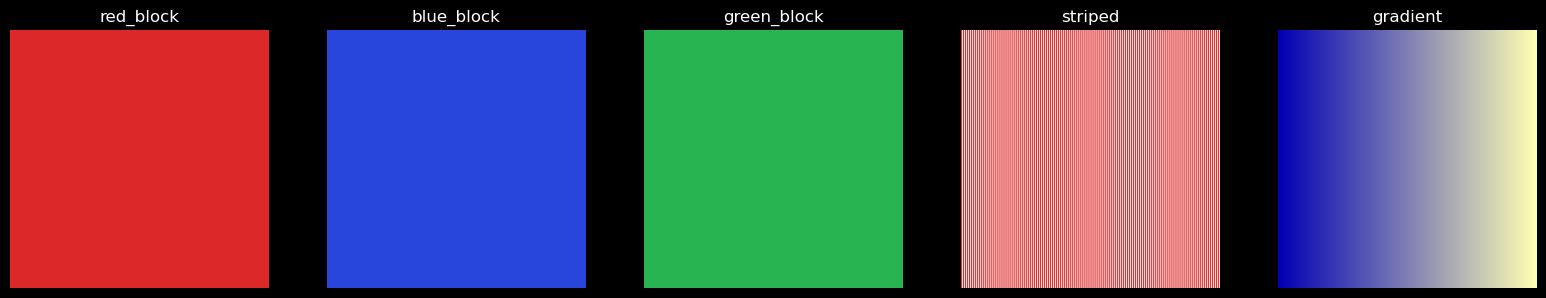

In [3]:
fig, axes = plt.subplots(1, len(paths), figsize=(16, 3))
for ax, (name, path) in zip(axes, paths.items()):
    ax.imshow(Image.open(path))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Section 3 Demo: Images as Data

This cell will help us see if an image is:
- a tensor / matrix of numbers
- not semantic meaning by itself

We inspect:
- shape
- data type
- RGB channel values


Shape: (256, 256, 3)
Data type: uint8
Top-left pixel RGB: [220  40  40]
Center pixel RGB: [220  40  40]


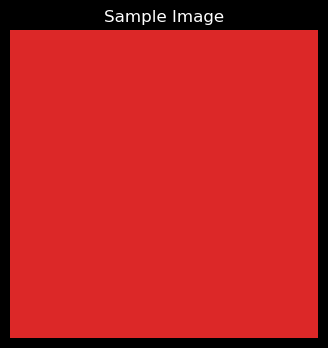

In [4]:
sample_img = np.array(Image.open(paths["red_block"]))
print("Shape:", sample_img.shape)        # height, width, channels
print("Data type:", sample_img.dtype)
print("Top-left pixel RGB:", sample_img[0, 0])
print("Center pixel RGB:", sample_img[128, 128])

plt.figure(figsize=(4,4))
plt.imshow(sample_img)
plt.title("Sample Image")
plt.axis("off")
plt.show()


In [5]:
# Zoom into a tiny pixel region for teaching purposes
tiny_patch = sample_img[:8, :8, :]
print("8x8 pixel patch:\n")
print(tiny_patch)


8x8 pixel patch:

[[[220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]]

 [[220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]]

 [[220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]]

 [[220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]]

 [[220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]]

 [[220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]]

 [[220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]]

 [[220  40  40]
  [220  40  40]
  [220  40  40]
  [220  40  40]
  [220  

Shape: (256, 256, 3)
Data type: uint8
Top-left pixel RGB: [  0   0 180]
Center pixel RGB: [128 128 180]


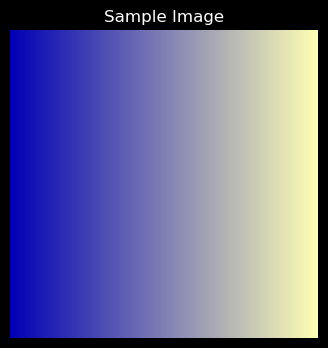

In [6]:
sample_img = np.array(Image.open(paths["gradient"]))
print("Shape:", sample_img.shape)        # height, width, channels
print("Data type:", sample_img.dtype)
print("Top-left pixel RGB:", sample_img[0, 0])
print("Center pixel RGB:", sample_img[128, 128])

plt.figure(figsize=(4,4))
plt.imshow(sample_img)
plt.title("Sample Image")
plt.axis("off")
plt.show()


In [7]:
# Zoom into a tiny pixel region for teaching purposes
tiny_patch = sample_img[:8, :8, :]
print("8x8 pixel patch:\n")
print(tiny_patch)


8x8 pixel patch:

[[[  0   0 180]
  [  1   1 180]
  [  2   2 180]
  [  3   3 180]
  [  4   4 180]
  [  5   5 180]
  [  6   6 180]
  [  7   7 180]]

 [[  0   0 180]
  [  1   1 180]
  [  2   2 180]
  [  3   3 180]
  [  4   4 180]
  [  5   5 180]
  [  6   6 180]
  [  7   7 180]]

 [[  0   0 180]
  [  1   1 180]
  [  2   2 180]
  [  3   3 180]
  [  4   4 180]
  [  5   5 180]
  [  6   6 180]
  [  7   7 180]]

 [[  0   0 180]
  [  1   1 180]
  [  2   2 180]
  [  3   3 180]
  [  4   4 180]
  [  5   5 180]
  [  6   6 180]
  [  7   7 180]]

 [[  0   0 180]
  [  1   1 180]
  [  2   2 180]
  [  3   3 180]
  [  4   4 180]
  [  5   5 180]
  [  6   6 180]
  [  7   7 180]]

 [[  0   0 180]
  [  1   1 180]
  [  2   2 180]
  [  3   3 180]
  [  4   4 180]
  [  5   5 180]
  [  6   6 180]
  [  7   7 180]]

 [[  0   0 180]
  [  1   1 180]
  [  2   2 180]
  [  3   3 180]
  [  4   4 180]
  [  5   5 180]
  [  6   6 180]
  [  7   7 180]]

 [[  0   0 180]
  [  1   1 180]
  [  2   2 180]
  [  3   3 180]
  [  4  

### Notes
The model does **not** begin with the concept “red object.”
It begins with structured numerical input.

That is why we need a representation layer that converts pixels into useful features.


## 3. Section 4 Demo: Visual Embeddings

Now we convert images into embeddings using a CLIP model.

Why CLIP (Contrastive Language-Image Pre-training)?
- It is widely used for image-text alignment.
- It gives a clean conceptual bridge:
  - image -> vector
  - text -> vector
  - similarity in a shared space


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

print("Loaded:", model_name)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Loaded: openai/clip-vit-base-patch32


In [10]:
def get_image_embedding(image_path: Path):
    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        # First try the normal CLIP helper
        feats = clip_model.get_image_features(**inputs)

        # Some transformers versions return a structured object instead of a tensor
        if not isinstance(feats, torch.Tensor):
            vision_outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])
            feats = vision_outputs.pooler_output

        feats = feats / feats.norm(dim=-1, keepdim=True)

    return feats.cpu().numpy()[0]

image_embeddings = {name: get_image_embedding(path) for name, path in paths.items()}

for name, emb in image_embeddings.items():
    print(name, emb.shape, "norm =", np.linalg.norm(emb).round(4))

# 1. (768,) → embedding size
# Each image is represented as a vector with 768 numbers

red_block (768,) norm = 1.0
blue_block (768,) norm = 1.0
green_block (768,) norm = 1.0
striped (768,) norm = 1.0
gradient (768,) norm = 1.0


In [11]:
# Show just the first few values to see the embedding is a dense vector
# So instead of storing the image as pixels, the model stores it as:
# [0.0089, -0.047, 0.0094, ..., 768 values total]

name = "striped"
print(f"First 12 values of the '{name}' embedding:")
print(np.round(image_embeddings[name][:12], 4))


First 12 values of the 'striped' embedding:
[ 0.0089 -0.047   0.0094 -0.0136  0.0413  0.0093  0.0313  0.0132  0.0479
  0.0304 -0.014  -0.0573]


## 4. Similarity Search in Embedding Space

This mirrors the logic from Week 8:
- query -> embedding
- compare vectors
- rank by similarity

Here the query can be an image.


In [12]:
def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

similarity_matrix = []
names = list(image_embeddings.keys())
for name_a in names:
    row = []
    for name_b in names:
        row.append(cosine_similarity(image_embeddings[name_a], image_embeddings[name_b]))
    similarity_matrix.append(row)

similarity_matrix = np.array(similarity_matrix)
similarity_matrix


array([[1.00000012, 0.86194134, 0.87278837, 0.69384509, 0.73962659],
       [0.86194134, 1.        , 0.89692116, 0.68454927, 0.82463109],
       [0.87278837, 0.89692116, 1.        , 0.68210495, 0.74879843],
       [0.69384509, 0.68454927, 0.68210495, 1.        , 0.62614357],
       [0.73962659, 0.82463109, 0.74879843, 0.62614357, 1.00000012]])

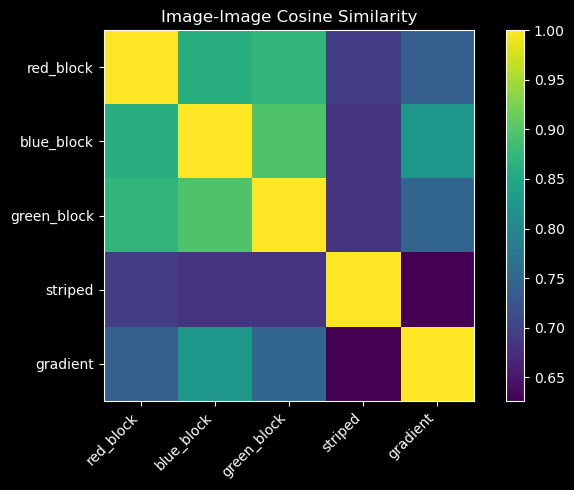

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(similarity_matrix, cmap="viridis")
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticklabels(names)
ax.set_title("Image-Image Cosine Similarity")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [14]:
# Retrieve the most similar images to a chosen query image
query_name = "red_block"
query_emb = image_embeddings[query_name]

ranked = sorted(
    [(name, cosine_similarity(query_emb, emb)) for name, emb in image_embeddings.items()],
    key=lambda x: x[1],
    reverse=True
)

print("Query image:", query_name)
for name, score in ranked:
    print(f"{name:12s} -> {score:.4f}")


Query image: red_block
red_block    -> 1.0000
green_block  -> 0.8728
blue_block   -> 0.8619
gradient     -> 0.7396
striped      -> 0.6938


### Note
At this stage, retrieval is a geometric operation.
The system does not “understand” the image in a human way—it compares learned representations.


## 5. Optional Visualization of Embedding Space

We reduce the high-dimensional embeddings to 2D using PCA just for visualization.
This is not the real embedding space; it is a simplified teaching view.


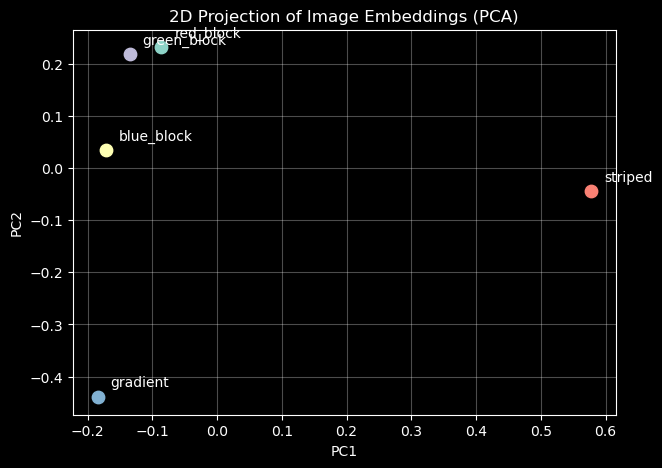

In [15]:
from sklearn.decomposition import PCA

X = np.vstack([image_embeddings[name] for name in names])
pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
for i, name in enumerate(names):
    plt.scatter(X2[i, 0], X2[i, 1], s=80)
    plt.text(X2[i, 0] + 0.02, X2[i, 1] + 0.02, name, fontsize=10)

plt.title("2D Projection of Image Embeddings (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()


## 6. Section 8 Demo: Basic Tagging / Labeling

Now we use zero-shot image classification.
This is a simple way to demonstrate:
- labels
- ranking
- confidence-like scores

Important note:
These scores are model-relative scores over candidate labels.
They are useful for ranking and thresholding, but they are not guaranteed truth.


In [16]:
classifier = pipeline(
    task="zero-shot-image-classification",
    model=model_name,
    device=0 if torch.cuda.is_available() else -1
)

candidate_labels = [
    "a red object",
    "a blue object",
    "a green object",
    "a striped pattern",
    "a gradient image",
    "a document",
    "an animal"
]

query_path = str(paths["striped"])
results = classifier(query_path, candidate_labels=candidate_labels)

results


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'score': 0.8994985222816467, 'label': 'a striped pattern'},
 {'score': 0.06789172440767288, 'label': 'a red object'},
 {'score': 0.031566377729177475, 'label': 'a gradient image'},
 {'score': 0.0004454864247236401, 'label': 'a blue object'},
 {'score': 0.00033715448807924986, 'label': 'an animal'},
 {'score': 0.00014677194121759385, 'label': 'a document'},
 {'score': 0.00011396736954338849, 'label': 'a green object'}]

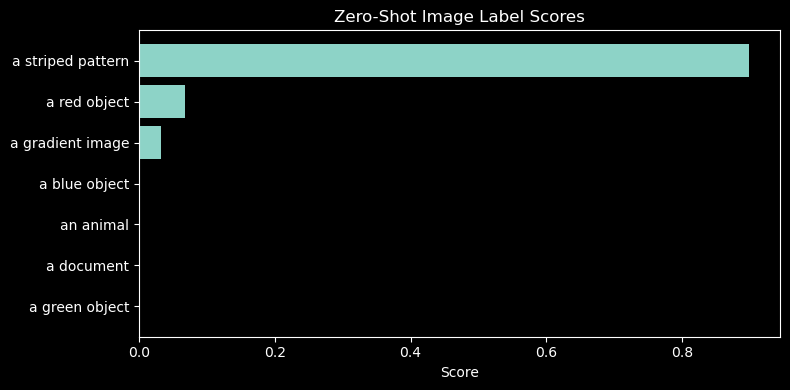

a striped pattern  -> 0.8995
a red object       -> 0.0679
a gradient image   -> 0.0316
a blue object      -> 0.0004
an animal          -> 0.0003
a document         -> 0.0001
a green object     -> 0.0001


In [17]:
labels = [r["label"] for r in results]
scores = [r["score"] for r in results]

plt.figure(figsize=(8, 4))
plt.barh(labels[::-1], scores[::-1])
plt.xlabel("Score")
plt.title("Zero-Shot Image Label Scores")
plt.tight_layout()
plt.show()

for r in results:
    print(f'{r["label"]:18s} -> {r["score"]:.4f}')


## 7. Confidence Threshold Demo

A threshold is a system rule:
- accept labels above threshold
- ignore or review labels below threshold

This is a product decision, not a law of nature.


In [18]:
threshold = 0.25
accepted = [r for r in results if r["score"] >= threshold]

print("Threshold:", threshold)
print("Accepted labels:")
for r in accepted:
    print(f'- {r["label"]}: {r["score"]:.4f}')


Threshold: 0.25
Accepted labels:
- a striped pattern: 0.8995


In [19]:
for threshold in [0.10, 0.25, 0.50, 0.75]:
    accepted = [r["label"] for r in results if r["score"] >= threshold]
    print(f"Threshold {threshold:.2f} -> {accepted}")


Threshold 0.10 -> ['a striped pattern']
Threshold 0.25 -> ['a striped pattern']
Threshold 0.50 -> ['a striped pattern']
Threshold 0.75 -> ['a striped pattern']


### Note
Higher threshold:
- fewer labels
- cleaner output

Lower threshold:
- more coverage
- more noise

This is exactly how model outputs become product behavior.


## 8. Summary

Notebook 1 demonstrated three ideas:

1. **Images are numerical inputs**
   - pixels first, meaning later

2. **Visual embeddings make similarity possible**
   - image -> vector
   - compare in embedding space

3. **Tagging scores become system decisions through thresholds**
   - model score -> rule -> behavior

This notebook sets up the next step:
- Notebook 2: image + prompt -> multimodal understanding
- Notebook 3: full multimodal pipeline
